In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
from scipy import linalg
import torch
from sklearn.manifold import TSNE
import umap.plot
from sklearn.preprocessing  import MinMaxScaler
from Bio import SeqIO

/doctorai/marinafr/progs/miniconda3/envs/airr_atlas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Numpy implementation of the Frechet Distance.
    The Frechet distance between two multivariate Gaussians X_1 ~ N(mu_1, C_1)
    and X_2 ~ N(mu_2, C_2) is
            d^2 = ||mu_1 - mu_2||^2 + Tr(C_1 + C_2 - 2*sqrt(C_1*C_2)).

    Stable version by Dougal J. Sutherland.
    Params:
    -- mu1:    The mean of the activations of preultimate layer of the
               CHEMNET (like returned by the function 'get_predictions')
               for generated samples.
    -- mu2:    The mean of the activations of preultimate layer of the
               CHEMNET (like returned by the function 'get_predictions')
               for real samples.
    -- sigma1: The covariance matrix of the activations of preultimate layer
               of the CHEMNET (like returned by the function 'get_predictions')
               for generated samples.
    -- sigma2: The covariance matrix of the activations of preultimate layer
               of the CHEMNET (like returned by the function 'get_predictions')
               for real samples.
    Returns:
    --   : The Frechet Distance.
    """

    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    assert (
        mu1.shape == mu2.shape
    ), "Training and test mean vectors have different lengths"
    assert (
        sigma1.shape == sigma2.shape
    ), "Training and test covariances have different dimensions"

    diff = mu1 - mu2

    # product might be almost singular
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # numerical error might give slight imaginary component
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            #raise ValueError("Imaginary component {}".format(m))
            print("Imaginary component {}".format(m))
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean

In [4]:
def get_w2(act1, act2):

    """Calculate w2 between two sets

    Args:
        act1: First set
        act2: Second set

    Returns:
        float: The FCD score
    """

    mu1 = np.mean(act1, axis=0)
    sigma1 = np.cov(act1.T)

    mu2 = np.mean(act2, axis=0)
    sigma2 = np.cov(act2.T)

    fcd_score = calculate_frechet_distance(
        mu1=mu1, mu2=mu2, sigma1=sigma1, sigma2=sigma2
    )

    return fcd_score

In [14]:
model_name = 'ohe'

if model_name == 'antiberta2':
    short_model_name = 'ab2'
else: 
    short_model_name = model_name

data = torch.load(f'<UPDATE_PATH>'  # TODO: update path to your data).numpy()

len(data)

524346

In [15]:
# Split the data into two halves
data1 = data[:len(data) // 2]
data2 = data[len(data) // 2 + 1:]

splits = [int(x) for x in [1000, 5000, 10**4, 3*10**4, 5*10**4, 10**5, 1.5*10**5, 2*10**5, 2.5*10**5]]
w2_data = []

num_repetitions = 10

for repetition in range(num_repetitions):
    print(repetition+1)
    w2_repetition = []

    # Shuffle data2 to ensure randomization
    np.random.shuffle(data2)

    for batch_size in splits:
        print(batch_size)
        max_start = len(data2) - batch_size
        if max_start <= 0:
            print('break')
            break
        start = np.random.randint(0, max_start)
        batch = data2[start:start + batch_size]
        w2_repetition.append(get_w2(batch, data1))
        print(get_w2(batch, data1))

    w2_data.append(w2_repetition)

# Create a DataFrame for boxplot
df = pd.DataFrame(w2_data, columns=splits)

df.to_csv(f"completeness_trastuzumab_{short_model_name}.csv", index=False)

df

1
1000
0.9865073509807232
5000
0.8349542120205555
10000
0.8015218157324249
30000
0.7972871982398111
50000
0.7878002599857261
100000
0.7873789496336112
150000
0.7869993600473535
200000
0.7874343765392631
250000
0.7858599082472715
2
1000
1.0176993384574882
5000
0.8324453782848416
10000
0.8165375628713267
30000
0.8003675973190081
50000
0.7917158077579565
100000
0.7855568821491801
150000
0.7842558147868637
200000
0.7848082648631571
250000
0.7852570652567614
3
1000
0.9983627481219983
5000
0.838327642092441
10000
0.7815586661210148
30000
0.7904778856807155
50000
0.7886626442189772
100000
0.7843409489188158
150000
0.78491429824372
200000
0.7840377022651488
250000
0.7846233380046836
4
1000
0.9622956601567125
5000
0.8310296449254615
10000
0.7991559849417698
30000
0.8079244195865876
50000
0.7932505248696184
100000
0.7918582971679236
150000
0.7915686480533459
200000
0.7881937472098457
250000
0.7853473028912799
5
1000
1.0730915778190528
5000
0.8309551573073293
10000
0.7855011443810582
30000
0.7899

,1000,5000,10000,30000,50000,100000,150000,200000,250000
0,0.986507,0.834954,0.801522,0.797287,0.787800,0.787379,0.786999,0.787434,0.785860
1,1.017699,0.832445,0.816538,0.800368,0.791716,0.785557,0.784256,0.784808,0.785257
2,0.998363,0.838328,0.781559,0.790478,0.788663,0.784341,0.784914,0.784038,0.784623
3,0.962296,0.831030,0.799156,0.807924,0.793251,0.791858,0.791569,0.788194,0.785347
4,1.073092,0.830955,0.785501,0.789901,0.783876,0.783972,0.787319,0.787160,0.785666
5,1.078161,0.820045,0.804247,0.788599,0.782733,0.787217,0.786605,0.785879,0.784827
6,1.061928,0.829712,0.806717,0.799086,0.797509,0.788879,0.789333,0.787688,0.785653
7,1.067210,0.862559,0.817614,0.789811,0.786797,0.784653,0.783591,0.782975,0.784587
8,1.061603,0.857011,0.807698,0.786631,0.791476,0.787051,0.786849,0.784261,0.785227
9,1.006436,0.845733,0.811106,0.799335,0.796463,0.784161,0.787367,0.784219,0.785816


# **Load precomputed w2**

In [ ]:
df_esm2 = pd.read_csv('data/completeness_trastuzumab_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_esm2

,1000,5000,10000,30000,50000,100000,150000,200000,250000
0,0.102078,0.081248,0.078228,0.072902,0.069480,0.070897,0.069616,0.069694,0.069691
1,0.103635,0.074600,0.068816,0.072598,0.069829,0.070483,0.069931,0.069436,0.069740
2,0.106778,0.080253,0.078100,0.071314,0.069951,0.070524,0.069943,0.069889,0.069667
3,0.087178,0.081810,0.071396,0.069735,0.071057,0.069952,0.070255,0.070132,0.069715
4,0.105863,0.078682,0.073135,0.072285,0.069992,0.070111,0.069690,0.069584,0.069631
5,0.100400,0.072457,0.071338,0.071043,0.070079,0.070209,0.069781,0.069450,0.069630
6,0.102590,0.076195,0.069389,0.075010,0.070650,0.070449,0.070277,0.069849,0.069790
7,-65532.219697,0.077767,0.072138,0.072479,0.071960,0.069507,0.069961,0.070188,0.069876
8,0.103309,0.084569,0.072316,0.071835,0.070442,0.069972,0.069456,0.069269,0.069732
9,87.759073,0.079041,0.073626,0.071876,0.070706,0.070296,0.069703,0.070216,0.069952


In [24]:
# e.g., anything with absolute value > 1 is impossible in this column
df_esm2.loc[df_esm2.iloc[:, 0].abs() > 1, df_esm2.columns[0]] = np.nan
df_esm2

,1000,5000,10000,30000,50000,100000,150000,200000,250000
0,0.102078,0.081248,0.078228,0.072902,0.069480,0.070897,0.069616,0.069694,0.069691
1,0.103635,0.074600,0.068816,0.072598,0.069829,0.070483,0.069931,0.069436,0.069740
2,0.106778,0.080253,0.078100,0.071314,0.069951,0.070524,0.069943,0.069889,0.069667
3,0.087178,0.081810,0.071396,0.069735,0.071057,0.069952,0.070255,0.070132,0.069715
4,0.105863,0.078682,0.073135,0.072285,0.069992,0.070111,0.069690,0.069584,0.069631
5,0.100400,0.072457,0.071338,0.071043,0.070079,0.070209,0.069781,0.069450,0.069630
6,0.102590,0.076195,0.069389,0.075010,0.070650,0.070449,0.070277,0.069849,0.069790
7,NaN,0.077767,0.072138,0.072479,0.071960,0.069507,0.069961,0.070188,0.069876
8,0.103309,0.084569,0.072316,0.071835,0.070442,0.069972,0.069456,0.069269,0.069732
9,NaN,0.079041,0.073626,0.071876,0.070706,0.070296,0.069703,0.070216,0.069952


In [25]:
df_ab2 = pd.read_csv('data/completeness_trastuzumab_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ab2

,1000,5000,10000,30000,50000,100000,150000,200000,250000
0,11.775900,6.871349,6.337050,5.958336,5.878169,5.781464,5.758753,5.767447,5.752287
1,11.930629,6.833986,6.495502,6.006149,5.825889,5.814169,5.771784,5.755291,5.755260
2,11.652817,7.088452,6.433938,5.948721,5.765354,5.772444,5.782819,5.762907,5.747183
3,12.148233,7.068671,6.309481,5.876377,5.880195,5.777159,5.744821,5.758508,5.742051
4,12.004214,6.825104,6.366471,6.060092,5.854639,5.818157,5.799720,5.797212,5.742415
5,12.046250,7.324408,6.362858,5.846055,5.827101,5.764410,5.739753,5.730449,5.746944
6,12.329309,6.987498,6.244531,5.801656,5.779106,5.776645,5.733426,5.746446,5.753701
7,12.257087,7.164570,6.298753,5.922147,5.760591,5.774868,5.790315,5.789375,5.762579
8,12.173822,7.214402,6.099564,5.847008,5.881709,5.787317,5.752285,5.753349,5.757719
9,11.988911,7.092347,6.223141,5.950205,5.861088,5.739190,5.738206,5.753928,5.741930


In [26]:
df_ohe = pd.read_csv('data/completeness_trastuzumab_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ohe

,1000,5000,10000,30000,50000,100000,150000,200000,250000
0,0.986507,0.834954,0.801522,0.797287,0.787800,0.787379,0.786999,0.787434,0.785860
1,1.017699,0.832445,0.816538,0.800368,0.791716,0.785557,0.784256,0.784808,0.785257
2,0.998363,0.838328,0.781559,0.790478,0.788663,0.784341,0.784914,0.784038,0.784623
3,0.962296,0.831030,0.799156,0.807924,0.793251,0.791858,0.791569,0.788194,0.785347
4,1.073092,0.830955,0.785501,0.789901,0.783876,0.783972,0.787319,0.787160,0.785666
5,1.078161,0.820045,0.804247,0.788599,0.782733,0.787217,0.786605,0.785879,0.784827
6,1.061928,0.829712,0.806717,0.799086,0.797509,0.788879,0.789333,0.787688,0.785653
7,1.067210,0.862559,0.817614,0.789811,0.786797,0.784653,0.783591,0.782975,0.784587
8,1.061603,0.857011,0.807698,0.786631,0.791476,0.787051,0.786849,0.784261,0.785227
9,1.006436,0.845733,0.811106,0.799335,0.796463,0.784161,0.787367,0.784219,0.785816


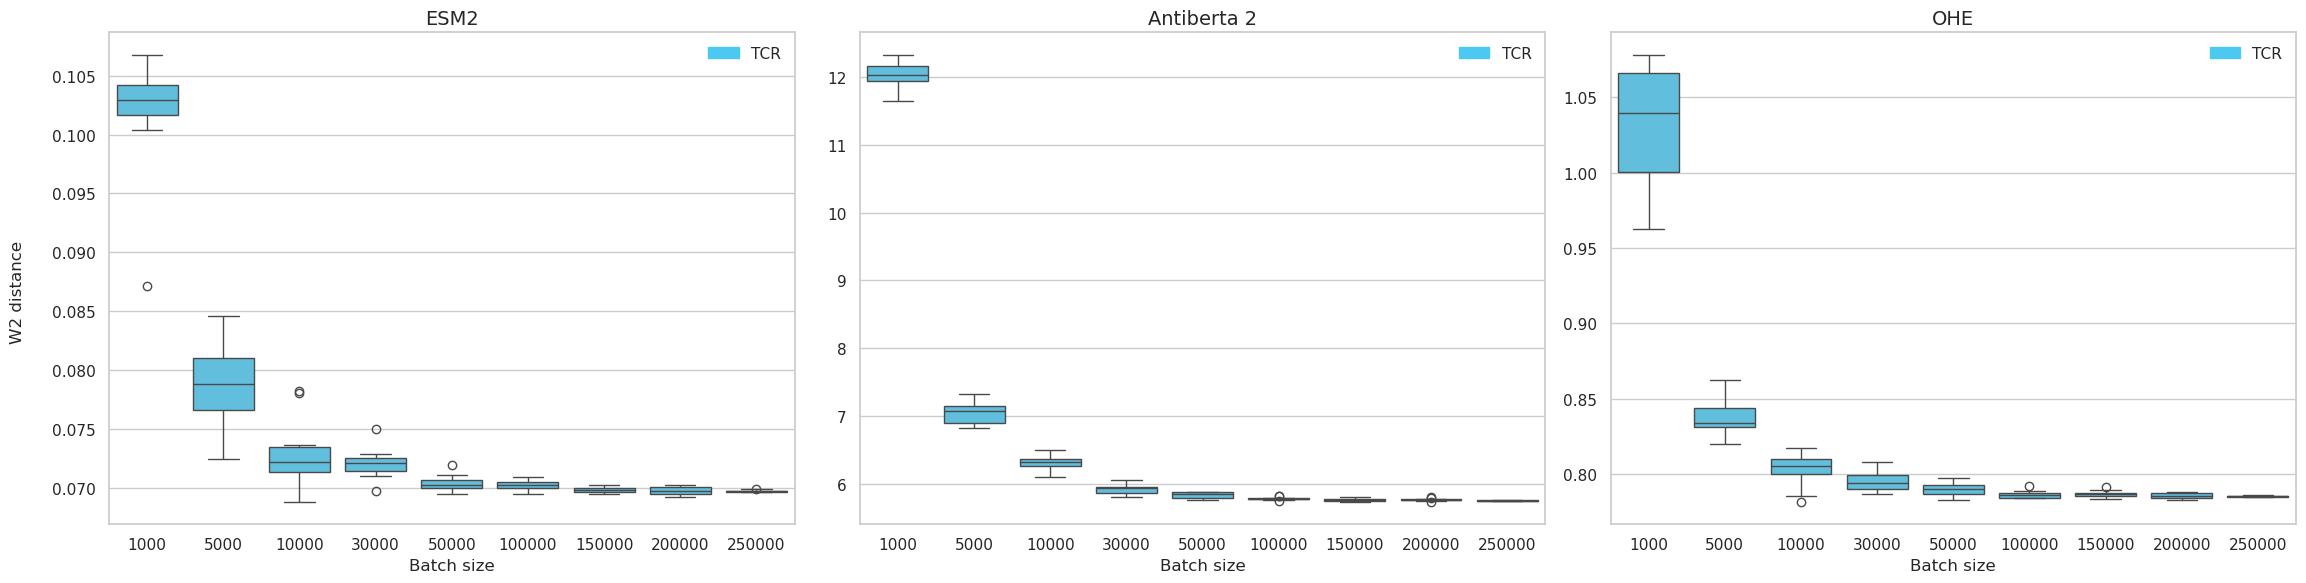

In [27]:
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Define a list of the dataframes and their titles
dataframes = [df_esm2, df_ab2, df_ohe]
titles = ['ESM2', 'Antiberta 2', 'OHE']

# Create a legend entry using a Patch for the specified color
legend_patch = Patch(color='#4CC9F0', label='TCR')

# Iterate over the list of dataframes and axes to plot each boxplot
for ax, df, title in zip(axes, dataframes, titles):
    sns.boxplot(data=df, orient="v", ax=ax, color='#4CC9F0')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    # Add the legend to each subplot
    ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, 'W2 distance', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

# Save the figure with a meaningful name
plt.savefig('completeness_trastuzumab.png')
plt.show()

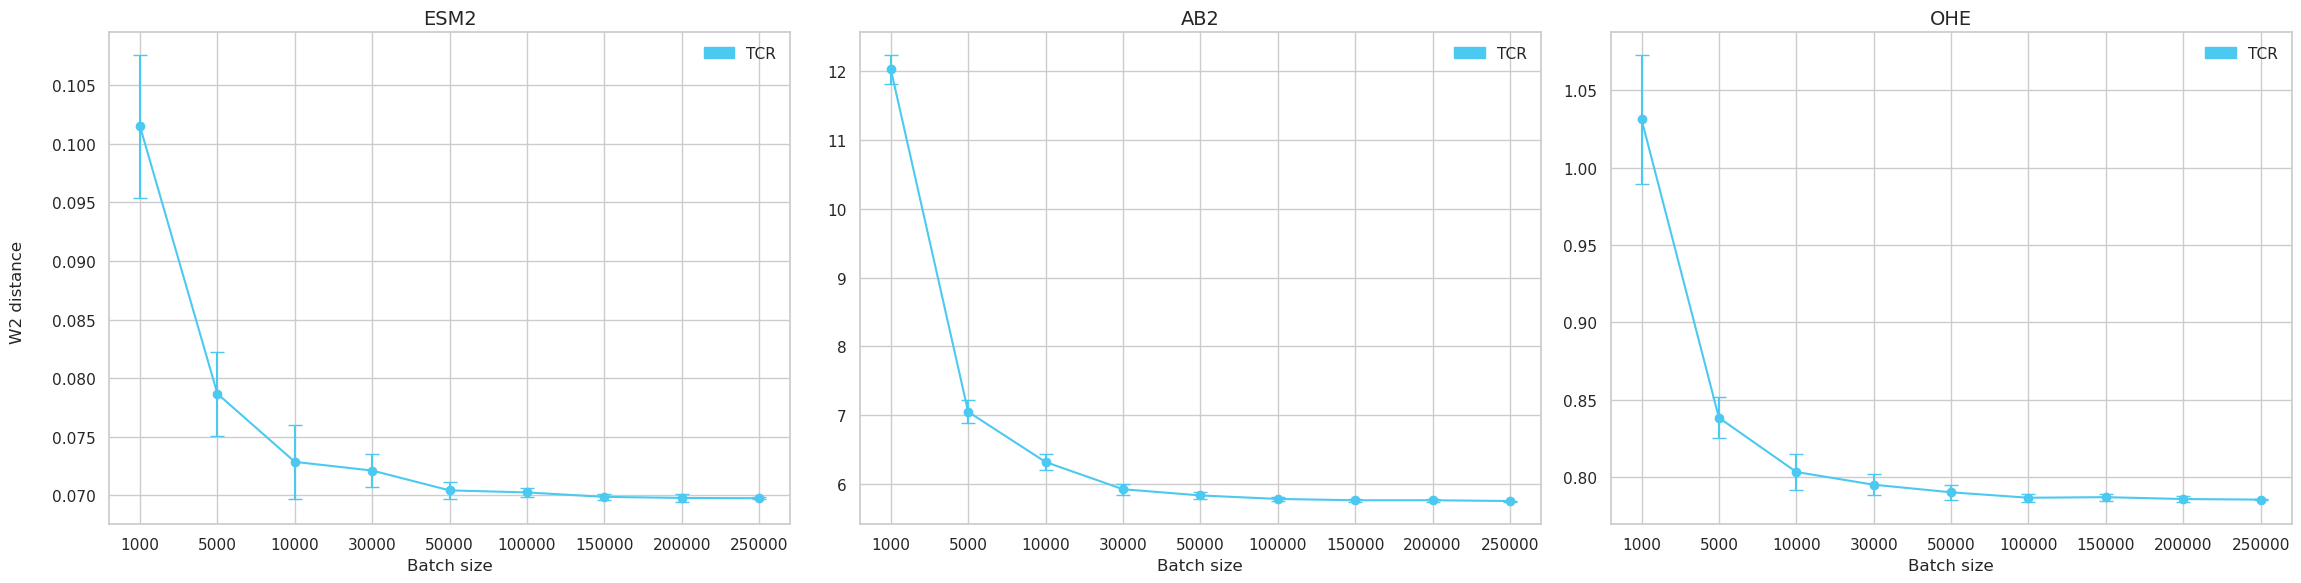

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Define the dataframes and their titles
dataframes = [df_esm2, df_ab2, df_ohe]
titles = ['ESM2', 'AB2', 'OHE']
color = '#4CC9F0'

# Create a legend patch
legend_patch = Patch(color=color, label='TCR')

# Plot error bars instead of boxplots
for ax, df, title in zip(axes, dataframes, titles):
    # Compute mean and std for each column
    means = df.mean()
    stds = df.std()
    x = np.arange(len(means))
    
    # Plot with error bars (connected dots with whiskers)
    ax.errorbar(x, means, yerr=stds, fmt='-o', color=color, capsize=5)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0)
    ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, 'W2 distance', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

# Save the figure
plt.savefig('completeness_trastuzumab.png')
plt.show()


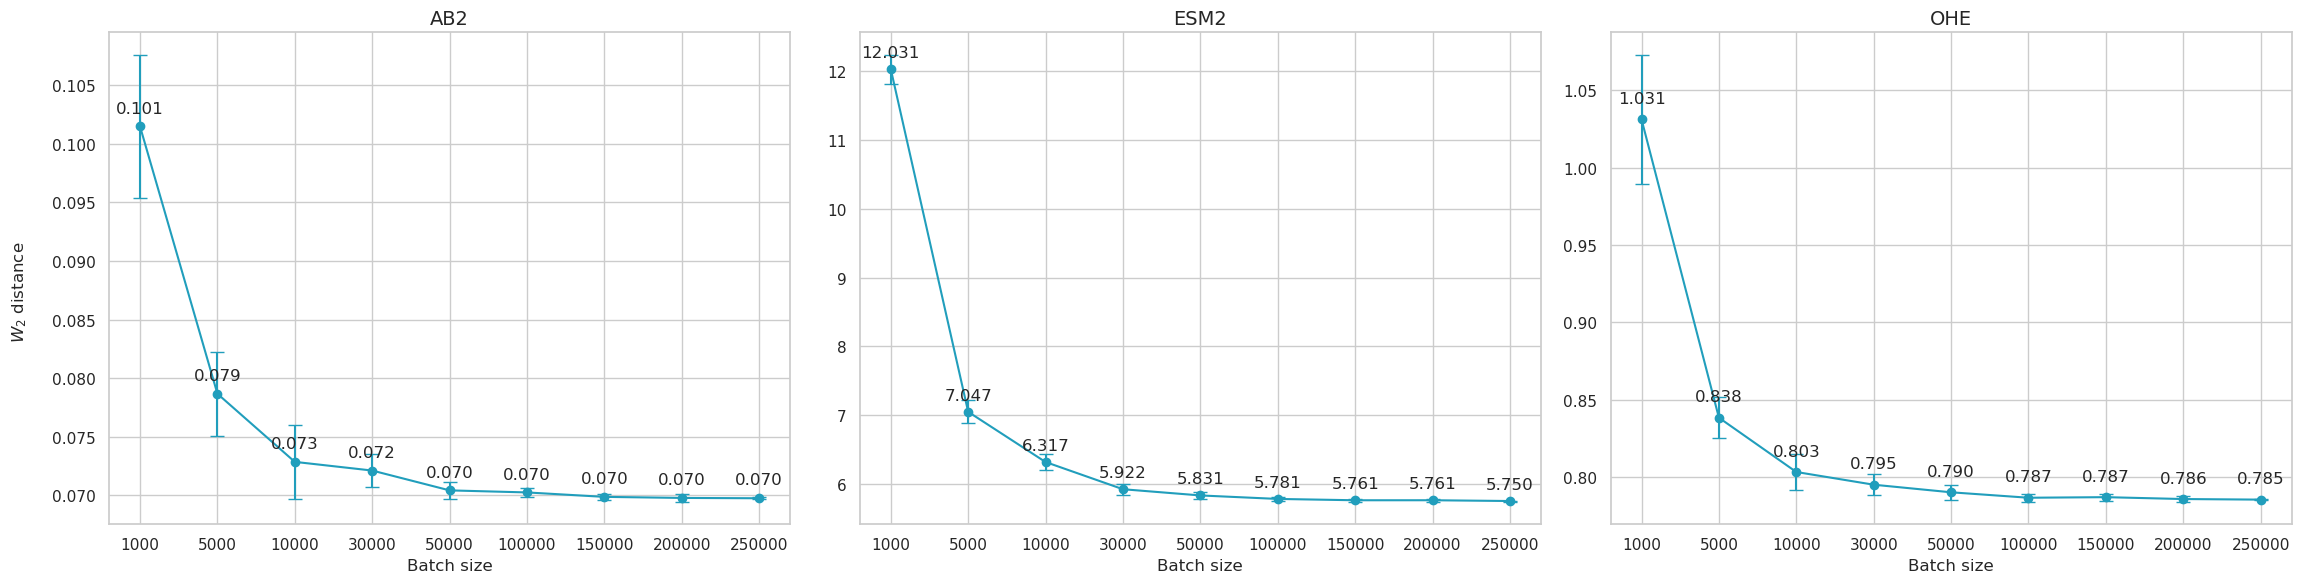

In [ ]:
sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Define the dataframes and their titles
dataframes = [df_esm2, df_ab2, df_ohe]
titles = ['AB2', 'ESM2', 'OHE']
color = '#219EBC'  # updated color

# Create a legend patch
#legend_patch = Patch(color=color, label='TCR')

# Plot error bars (connected dots with whiskers) and add numeric labels above markers
for ax, df, title in zip(axes, dataframes, titles):
    means = df.mean()
    stds = df.std()
    x = np.arange(len(means))

    # Plot with error bars
    line = ax.errorbar(x, means, yerr=stds, fmt='-o', color=color, capsize=5)

    # Determine a reasonable vertical offset for labels
    y_range = (means.max() - means.min()) if len(means) > 1 else (stds.max() if len(stds) > 0 else 1.0)
    offset = 0.006 * (means.max() if means.max() != 0 else 1.0) + 0.01 * y_range

    # Add labels above each point
    for xi, yi in zip(x, means):
        ax.text(xi, yi + offset, f'{yi:.3f}', ha='center', va='bottom', fontsize=12)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0)
    # ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, r"$W_2$ distance", va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

# Save the figure
plt.savefig('completeness_trastuzumab.png', dpi=300, bbox_inches='tight')
plt.show()

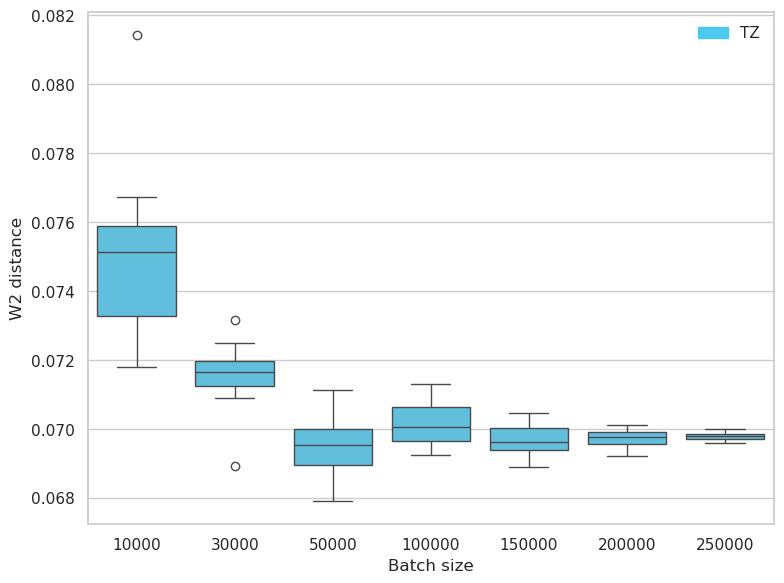

In [8]:
from matplotlib.patches import Patch

sns.set_style("whitegrid")

# Define a list of the dataframes and their titles
dataframes = [df_esm2]#, df_ab2, df_ohe]
titles = ['ESM2']#, 'Antiberta 2', 'OHE']

# Create a legend entry using a Patch for the specified color
legend_patch = Patch(color='#4CC9F0', label='TZ')

# Iterate over the list of dataframes and titles to plot each boxplot separately
for df, title in zip(dataframes, titles):
    # Create a figure and axes for the current subplot
    fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size as needed

    # Plot the boxplot on the current axes
    sns.boxplot(data=df, orient="v", ax=ax, color='#4CC9F0')

    # Set the title and labels for the current subplot
    #ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    ax.set_ylabel('W2 distance', fontsize=12)  # Add y-axis label

    # Add the legend to the current subplot
    ax.legend(handles=[legend_patch], loc='upper right', frameon=False)

    # Adjust layout for the current subplot
    plt.tight_layout()

    # Save the current subplot with a meaningful name
    plt.savefig(f'completeness_trastuzumab_{title}.png')

    # Display the current subplot
    plt.show()

# **Baseline**

In [8]:
df_esm2 = pd.read_csv('data/completeness_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_esm2

,10000,30000,50000,100000,150000,200000,300000,399990
0,0.009427,0.003354,0.002171,0.001285,0.000910,0.000735,0.000568,0.000492
1,0.010440,0.003570,0.002169,0.001212,0.000917,0.000747,0.000588,0.000493
2,0.008856,0.003550,0.002198,0.001261,0.000901,0.000732,0.000566,0.000493
3,0.009611,0.003694,0.002364,0.001291,0.000915,0.000766,0.000579,0.000492
4,0.009510,0.003659,0.002255,0.001246,0.000926,0.000741,0.000581,0.000493
5,0.010012,0.003645,0.002217,0.001240,0.000873,0.000740,0.000563,0.000492
6,0.009574,0.003555,0.002268,0.001302,0.000958,0.000781,0.000594,0.000492
7,0.009056,0.003679,0.002287,0.001263,0.000892,0.000744,0.000577,0.000492
8,0.010174,0.003380,0.002213,0.001227,0.000909,0.000754,0.000574,0.000493
9,0.009123,0.003442,0.002200,0.001324,0.000881,0.000730,0.000579,0.000493


In [9]:
df_ab2 = pd.read_csv('data/completeness_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ab2

,10000,30000,50000,100000,150000,200000,300000,399990
0,0.987929,0.347906,0.218036,0.122094,0.088788,0.073839,0.056981,0.048523
1,0.989028,0.344682,0.219129,0.122890,0.089616,0.072492,0.056383,0.048525
2,0.969796,0.339324,0.216139,0.121106,0.088112,0.072291,0.056113,0.048514
3,0.974066,0.342969,0.216737,0.120340,0.089483,0.071701,0.056161,0.048520
4,0.995610,0.347208,0.214505,0.121455,0.087851,0.072518,0.056241,0.048523
5,0.992682,0.345637,0.213787,0.120442,0.086802,0.071544,0.055913,0.048525
6,0.985977,0.337354,0.217957,0.121152,0.088888,0.072754,0.056164,0.048520
7,0.991912,0.348517,0.219100,0.122972,0.088285,0.072886,0.056864,0.048523
8,0.981738,0.350118,0.216903,0.121343,0.087535,0.072653,0.056312,0.048520
9,0.995951,0.346384,0.213699,0.119919,0.088177,0.071643,0.055934,0.048516


In [10]:
df_ohe = pd.read_csv('data/completeness_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_ohe

,10000,30000,50000,100000,150000,200000,300000,399900
0,0.106248,0.040258,0.026489,0.015763,0.011680,0.009412,0.007893,0.006940
1,0.110635,0.039163,0.025739,0.015136,0.011678,0.009707,0.007649,0.006940
2,0.105851,0.040933,0.027203,0.016011,0.010998,0.009359,0.008073,0.006940
3,0.115131,0.039527,0.026063,0.015595,0.011316,0.009635,0.008023,0.006940
4,0.107298,0.039474,0.025206,0.014561,0.011607,0.009315,0.007884,0.006939
5,0.107879,0.039495,0.024635,0.015336,0.011794,0.010127,0.007876,0.006940
6,0.113597,0.039387,0.025818,0.015302,0.011990,0.009518,0.007667,0.006940
7,0.106899,0.042400,0.027184,0.016205,0.012100,0.010404,0.007996,0.006941
8,0.105065,0.039430,0.025198,0.014988,0.011549,0.009663,0.007780,0.006938
9,0.109467,0.039181,0.026303,0.014834,0.012373,0.010269,0.008139,0.006938


In [11]:
df_b_1p_esm2 = pd.read_csv('data/baseline_1_patient_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_1p_esm2

,10000,30000,50000,100000,150000,200000,300000,399900
0,0.010725,0.005719,0.004735,0.003870,0.003538,0.003235,0.003086,0.002896
1,0.011716,0.005894,0.004206,0.003730,0.003647,0.003224,0.003033,0.002891
2,0.010841,0.006266,0.004739,0.003478,0.003260,0.003120,0.002940,0.002893
3,0.011404,0.005437,0.004522,0.003499,0.003258,0.003248,0.003026,0.002897
4,0.013282,0.005666,0.004280,0.003561,0.003192,0.003103,0.002973,0.002897
5,0.012121,0.005789,0.004509,0.003698,0.003404,0.003192,0.003009,0.002895
6,0.012019,0.005902,0.004390,0.003534,0.003234,0.003175,0.002965,0.002892
7,0.012261,0.005708,0.004590,0.003608,0.003207,0.003177,0.002939,0.002897
8,0.010402,0.006195,0.004248,0.003841,0.003473,0.003187,0.003002,0.002894
9,0.012108,0.006147,0.004766,0.003263,0.003436,0.003047,0.002976,0.002896


In [12]:
df_b_2p_esm2 = pd.read_csv('data/baseline_2_patients_esm2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_2p_esm2

,10000,30000,50000,100000,150000,200000,300000,399900
0,0.090328,0.079527,0.083468,0.084730,0.081843,0.083808,0.083578,0.082861
1,0.093896,0.086346,0.085509,0.084169,0.083442,0.083550,0.083691,0.082887
2,0.092302,0.086322,0.082010,0.082471,0.083613,0.081941,0.082380,0.082876
3,0.090757,0.086611,0.084302,0.083861,0.082653,0.083687,0.082941,0.082866
4,0.091351,0.082280,0.084694,0.081497,0.083612,0.082407,0.082796,0.082888
5,0.093494,0.088024,0.083163,0.081430,0.083401,0.083887,0.082850,0.082875
6,0.096768,0.087890,0.084893,0.084009,0.084179,0.084035,0.083304,0.082855
7,0.086249,0.085581,0.085897,0.083937,0.082999,0.082776,0.082918,0.082860
8,0.090063,0.085373,0.084992,0.083710,0.082556,0.082199,0.082090,0.082871
9,0.097659,0.084167,0.085383,0.082629,0.082967,0.082681,0.082967,0.082866


In [13]:
df_b_1p_ab2 = pd.read_csv('data/baseline_1_patient_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_1p_ab2

,10000,30000,50000,100000,150000,200000,300000,399900
0,1.175678,0.516965,0.372215,0.283504,0.249739,0.237612,0.224592,0.213147
1,1.100440,0.500385,0.398072,0.284610,0.252864,0.235771,0.220941,0.213139
2,1.149012,0.534190,0.360207,0.281294,0.241702,0.234943,0.218373,0.213032
3,1.135438,0.503535,0.364269,0.289557,0.249319,0.232329,0.219861,0.213157
4,1.121937,0.497094,0.380148,0.280750,0.254163,0.239803,0.225091,0.213100
5,1.148002,0.511794,0.369945,0.288047,0.260891,0.231760,0.225384,0.213067
6,1.118634,0.515481,0.380136,0.299621,0.253735,0.232154,0.218560,0.213188
7,1.084692,0.502604,0.376191,0.289100,0.238919,0.236020,0.218047,0.213044
8,1.084263,0.499454,0.372349,0.282561,0.255359,0.236980,0.220388,0.213066
9,1.153348,0.527879,0.355870,0.282829,0.256133,0.238117,0.220493,0.213171


In [14]:
df_b_2p_ab2 = pd.read_csv('data/baseline_2_patients_ab2.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_2p_ab2

,10000,30000,50000,100000,150000,200000,300000,399900
0,6.831248,6.446989,6.326689,6.178029,6.048712,6.163401,6.077922,6.073834
1,6.904728,6.352722,6.274394,6.087423,6.078667,6.108583,6.086420,6.074205
2,7.009840,6.255099,6.302943,6.157638,6.153348,6.129120,6.081052,6.073676
3,6.967499,6.412125,6.083150,6.085388,6.115941,6.087233,6.089696,6.073576
4,7.053746,6.367964,6.176808,6.171244,6.123402,6.101583,6.094132,6.073257
5,7.071902,6.366777,6.114569,6.125651,6.110951,6.099380,6.057654,6.072765
6,6.623657,6.374505,6.226401,6.153304,6.150449,6.107461,6.071280,6.074009
7,7.197788,6.538563,6.188590,6.034228,6.092509,6.128650,6.080758,6.074148
8,6.919138,6.196981,6.331735,6.085311,6.084681,6.039775,6.082635,6.073331
9,7.009778,6.437048,6.261266,6.065712,6.140073,6.059897,6.089339,6.074289


In [15]:
df_b_1p_ohe = pd.read_csv('data/baseline_1_patient_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_1p_ohe

,10000,30000,50000,100000,150000,200000,300000,399900
0,0.104074,0.047166,0.031140,0.025974,0.020667,0.019111,0.017906,0.017146
1,0.107198,0.047400,0.032220,0.024080,0.021905,0.019511,0.017781,0.017147
2,0.105617,0.045250,0.033469,0.024489,0.021042,0.019610,0.017945,0.017135
3,0.106442,0.045162,0.034468,0.024980,0.022519,0.019239,0.018152,0.017139
4,0.109850,0.047480,0.034305,0.024346,0.021748,0.019908,0.017524,0.017146
5,0.107245,0.044387,0.034082,0.023844,0.020550,0.018783,0.017739,0.017140
6,0.106920,0.045834,0.033958,0.024217,0.020998,0.019832,0.018237,0.017150
7,0.106993,0.044476,0.033520,0.024007,0.020756,0.019073,0.018115,0.017140
8,0.103057,0.046021,0.034176,0.023964,0.020933,0.019114,0.017831,0.017134
9,0.108064,0.044092,0.032519,0.024477,0.021425,0.019542,0.017663,0.017144


In [16]:
df_b_2p_ohe = pd.read_csv('data/baseline_2_patients_ohe.csv', usecols=lambda column: column != 'Unnamed: 0')
df_b_2p_ohe

,10000,30000,50000,100000,150000,200000,300000,399900
0,0.514930,0.434226,0.421906,0.411037,0.403993,0.404628,0.401532,0.400137
1,0.492004,0.424125,0.416860,0.410692,0.404425,0.402489,0.402375,0.400139
2,0.517940,0.438004,0.417692,0.411242,0.403179,0.404110,0.402116,0.400161
3,0.499635,0.422685,0.416220,0.409264,0.402592,0.405945,0.401772,0.400179
4,0.492436,0.434872,0.418071,0.407741,0.402584,0.401059,0.400794,0.400183
5,0.497606,0.438394,0.417340,0.404373,0.404748,0.399292,0.400234,0.400122
6,0.491919,0.434336,0.422524,0.410091,0.404356,0.402272,0.400708,0.400175
7,0.497237,0.438109,0.423406,0.405142,0.408157,0.404517,0.402826,0.400181
8,0.503588,0.422550,0.419044,0.415078,0.405977,0.406172,0.402318,0.400168
9,0.500051,0.435147,0.420007,0.411945,0.402756,0.402062,0.401288,0.400140


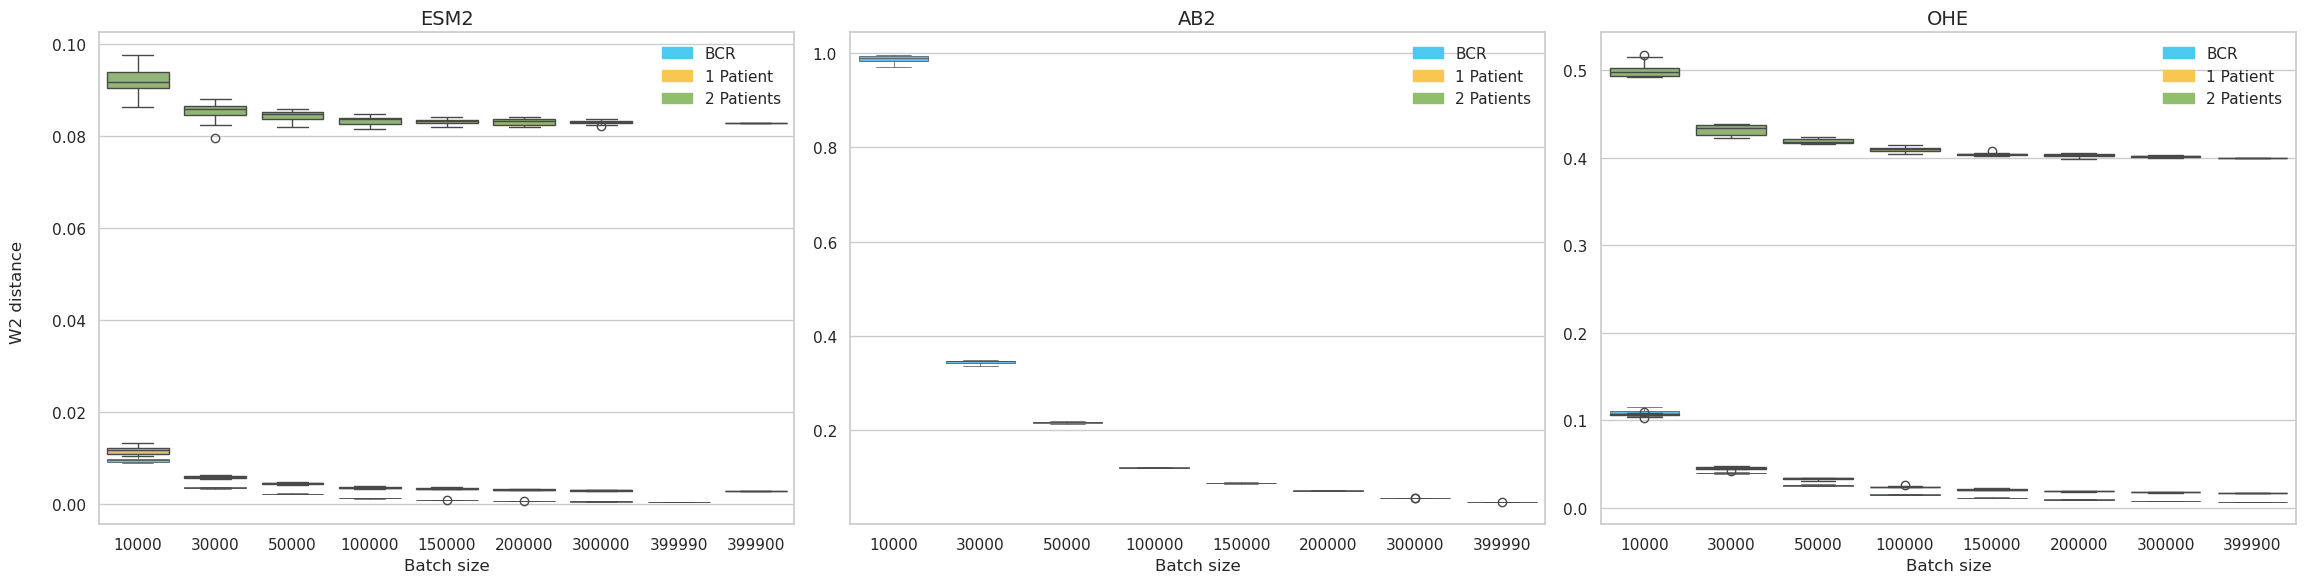

In [17]:
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Define a list of the dataframes and their titles
dataframes = [df_esm2, df_b_1p_esm2, df_b_2p_esm2, df_ab2, df_b_1p_ab2, df_b_2p_ab2, df_ohe, df_b_1p_ohe, df_b_2p_ohe]
titles = ['ESM2', 'AB2', 'OHE']
labels = ['BCR', '1 Patient', '2 Patients']

# Create legend patches for the specified colors
legend_patches = [Patch(color='#4CC9F0', label='BCR'),
                  Patch(color='#F9C74F', label='1 Patient'),
                  Patch(color='#90BE6D', label='2 Patients')]

# Iterate over the first 3 dataframes and axes to plot the boxplots
for ax, (df_title, df) in zip(axes, zip(titles, [df_esm2, df_ab2, df_ohe])):
    sns.boxplot(data=df, orient="v", ax=ax, color='#4CC9F0', linewidth=0.5)
    ax.set_title(df_title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)

    # Add new boxplots for additional dataframes corresponding to each title
    if df_title == 'ESM2':
        sns.boxplot(data=df_b_1p_esm2, orient="v", ax=ax, color='#F9C74F')
        sns.boxplot(data=df_b_2p_esm2, orient="v", ax=ax, color='#90BE6D')
    elif df_title == 'Antiberta 2':
        sns.boxplot(data=df_b_1p_ab2, orient="v", ax=ax, color='#F9C74F')
        sns.boxplot(data=df_b_2p_ab2, orient="v", ax=ax, color='#90BE6D')
    elif df_title == 'OHE':
        sns.boxplot(data=df_b_1p_ohe, orient="v", ax=ax, color='#F9C74F')
        sns.boxplot(data=df_b_2p_ohe, orient="v", ax=ax, color='#90BE6D')

    # Add the legend to each subplot
    ax.legend(handles=legend_patches, loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, 'W2 distance', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

# Save the figure with a meaningful name
#plt.savefig('baseline_completeness.png')
plt.show()


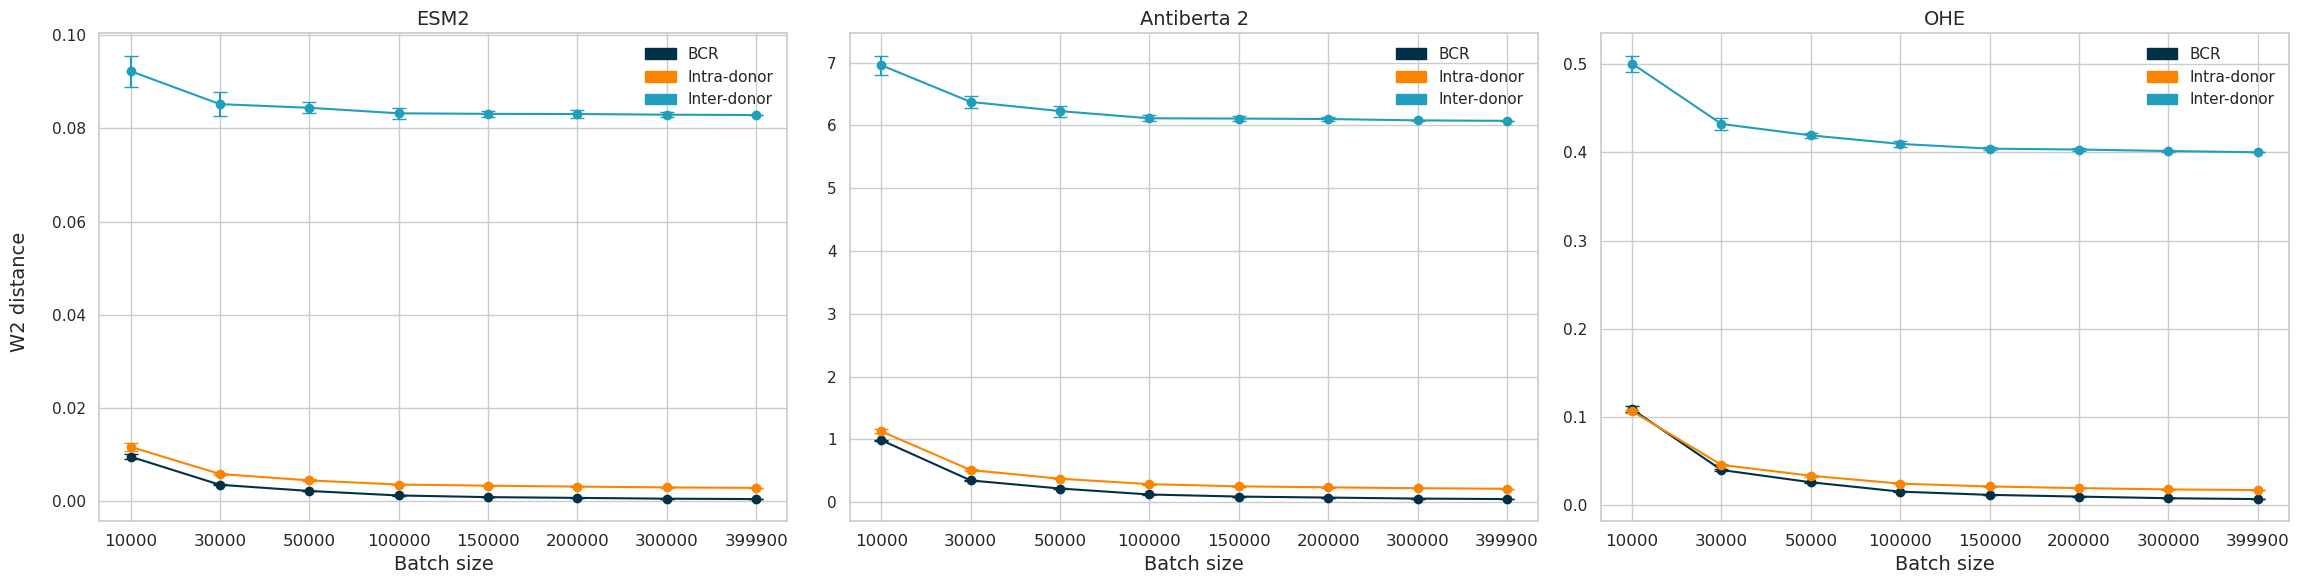

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# DataFrames: assume they all have the same column names (e.g., batch sizes)
titles = ['ESM2', 'Antiberta 2', 'OHE']
labels = ['BCR', 'Intra-donor', 'Inter-donor']
colors = ['#023047', '#FB8500', '#219EBC']

# Grouped datasets
datasets = [
    [df_esm2, df_b_1p_esm2, df_b_2p_esm2],
    [df_ab2, df_b_1p_ab2, df_b_2p_ab2],
    [df_ohe, df_b_1p_ohe, df_b_2p_ohe]
]

# Create legend patches
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l) for c, l in zip(colors, labels)]

# Plot connected means with error bars (whiskers as std)
for ax, title, dfs in zip(axes, titles, datasets):
    for df, label, color in zip(dfs, labels, colors):
        # Compute mean and std per column
        means = df.mean()
        stds = df.std()
        x = np.arange(len(means))
        
        # Plot with error bars
        ax.errorbar(x, means, yerr=stds, label=label, fmt='-o', color=color, capsize=5)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0, fontsize=12)
    ax.legend(handles=legend_patches, loc='upper right', frameon=False)

# Set the y-axis label for the entire figure
fig.text(0.04, 0.5, 'W2 distance', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

plt.savefig('baseline_completeness.png')
plt.show()


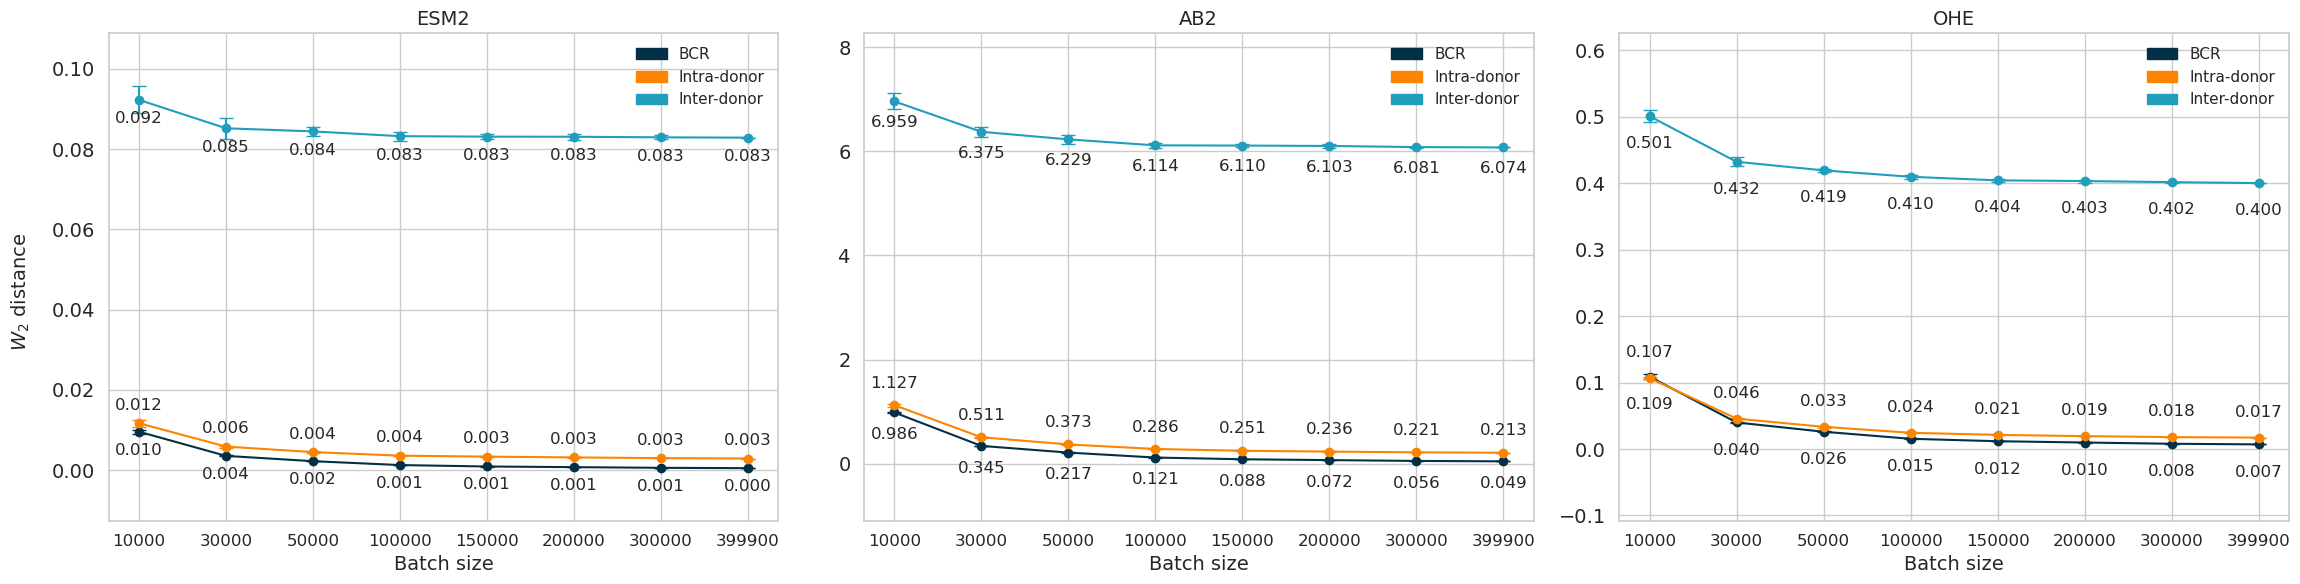

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

# Create a figure with 3 subplots, arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# DataFrames: assume they all have the same column names (e.g., batch sizes)
titles = ['ESM2', 'AB2', 'OHE']
labels = ['BCR', 'Intra-donor', 'Inter-donor']
colors = ['#023047', '#FB8500', '#219EBC']

# Grouped datasets
datasets = [
    [df_esm2, df_b_1p_esm2, df_b_2p_esm2],
    [df_ab2, df_b_1p_ab2, df_b_2p_ab2],
    [df_ohe, df_b_1p_ohe, df_b_2p_ohe]
]

# Create legend patches
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l) for c, l in zip(colors, labels)]

# Plot connected means with error bars (whiskers as std)
for ax, title, dfs in zip(axes, titles, datasets):
    all_means = []

    for df, label, color in zip(dfs, labels, colors):
        means = df.mean()
        stds = df.std()
        x = np.arange(len(means))
        all_means.extend(means)

        ax.errorbar(x, means, yerr=stds, label=label, fmt='-o', color=color, capsize=5)

        # Dynamic offset
        y_range = means.max() - means.min()
        offset = y_range * 0.3 if y_range > 0 else 0.1

        # Place labels above or below depending on the line
        for xi, yi in zip(x, means):
            if label == 'Intra-donor':
                ax.text(xi, yi + offset, f'{yi:.3f}', ha='center', va='bottom', fontsize=12)  # Above
            else:
                ax.text(xi, yi - offset, f'{yi:.3f}', ha='center', va='top', fontsize=12)     # Below

    # Set title and labels
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Batch size', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df.columns, rotation=0, fontsize=12)
    ax.tick_params(axis='y', labelsize=14)

    # Expand y-limits to prevent clipping
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - y_range * 0.9, ymax + y_range * 0.9)

    ax.legend(handles=legend_patches, loc='upper right', frameon=False)


# Set the y-axis label for the entire figure
#fig.text(0.04, 0.5, r'W_2 distance', va='center', rotation='vertical', fontsize=14)
fig.text(0.04, 0.5, r"$W_2$ distance",
         va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0, 1, 1])  # Adjust layout to accommodate y-axis label

plt.savefig('baseline_completeness.png')
plt.show()


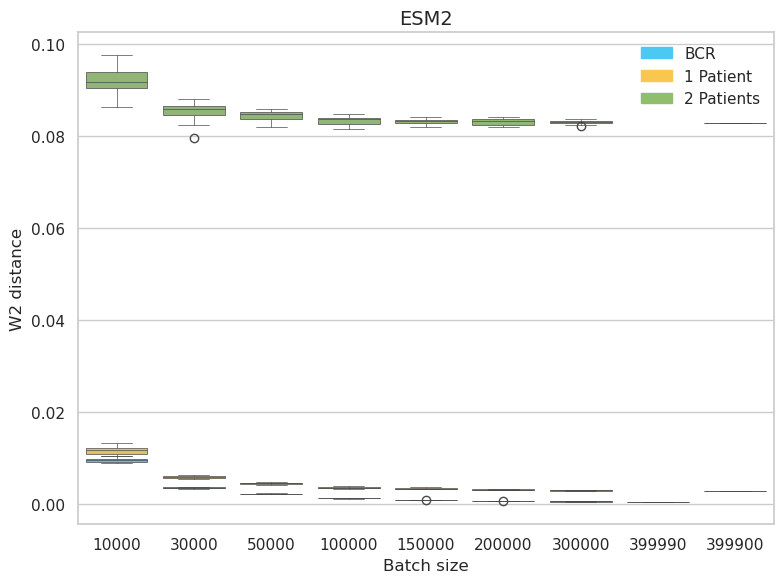

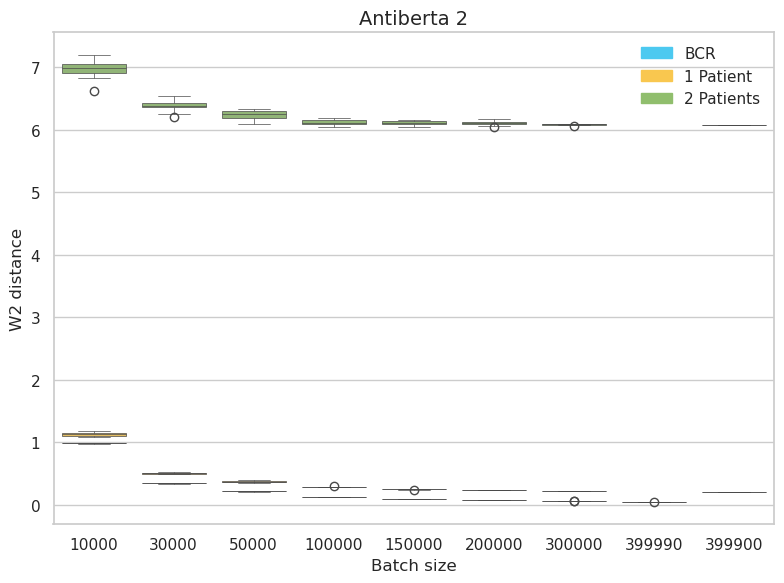

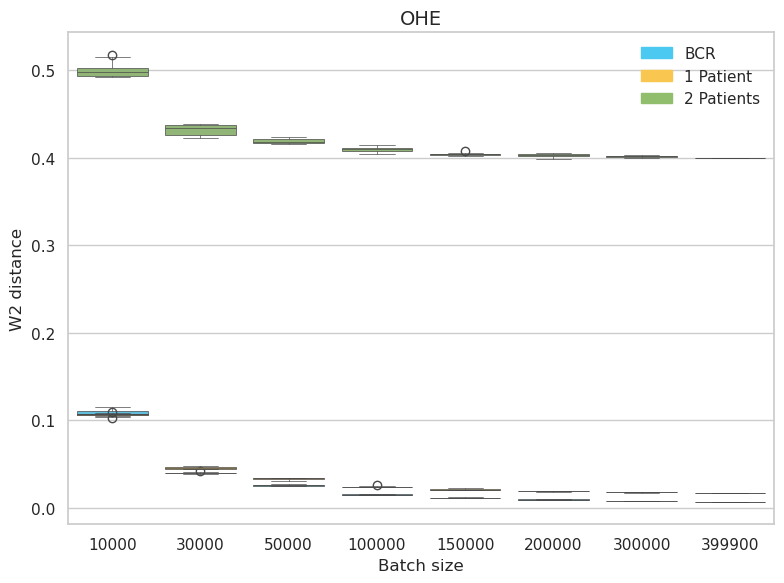

In [31]:
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for seaborn
sns.set_style("whitegrid")

# Define the list of titles and dataframes for each plot
data_info = [
    {
        'title': 'ESM2',
        'dataframes': [df_esm2, df_b_1p_esm2, df_b_2p_esm2],
        'colors': ['#4CC9F0', '#F9C74F', '#90BE6D']
    },
    {
        'title': 'Antiberta 2',
        'dataframes': [df_ab2, df_b_1p_ab2, df_b_2p_ab2],
        'colors': ['#4CC9F0', '#F9C74F', '#90BE6D']
    },
    {
        'title': 'OHE',
        'dataframes': [df_ohe, df_b_1p_ohe, df_b_2p_ohe],
        'colors': ['#4CC9F0', '#F9C74F', '#90BE6D']
    }
]

# Create a legend for the boxplots
legend_patches = [
    Patch(color='#4CC9F0', label='BCR'),
    Patch(color='#F9C74F', label='1 Patient'),
    Patch(color='#90BE6D', label='2 Patients')
]

# Iterate over the data information to create individual plots
for info in data_info:
    fig, ax = plt.subplots(figsize=(8, 6))  # Create a new figure for each dataset
    for df, color in zip(info['dataframes'], info['colors']):
        sns.boxplot(data=df, orient="v", ax=ax, color=color, linewidth=0.5)
    
    # Set the title and labels
    ax.set_title(info['title'], fontsize=14)
    ax.set_xlabel('Batch size', fontsize=12)
    
    # Add the legend
    ax.legend(handles=legend_patches, loc='upper right', frameon=False)
    
    # Set the y-axis label
    ax.set_ylabel('W2 distance', fontsize=12)
    
    # Save the figure with a meaningful name
    plt.tight_layout()
    plt.savefig(f'baseline_completeness_{info["title"].lower()}.png')
    plt.show()  # Show the plot
